# Predicción de Riesgo de Diabetes con Machine Learning

Este proyecto tiene como objetivo desarrollar un modelo predictivo que permita identificar el riesgo de diabetes tipo 2 en pacientes, utilizando un conjunto de datos clínicos. 

# Importación de bibliotecas

In [250]:
import warnings
warnings.filterwarnings("ignore", message="IProgress not found")

In [251]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, 
                            roc_curve, roc_auc_score, precision_recall_curve, auc)
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
import joblib

import shap
shap.initjs()
from IPython.display import display
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_validate


# Configuración de visualizaciones

In [252]:
plt.style.use('ggplot')
sns.set_palette("husl")
%matplotlib inline

# 1. Carga y Análisis Exploratorio de Datos (EDA)

## Cargar datos

In [253]:
data = pd.read_csv('https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv')
print("Dimensiones del dataset:", data.shape)
data.head()

Dimensiones del dataset: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 1. Análisis del dataset

In [254]:
print("\nInformación del dataset:")
print(data.info())
print("\nEstadísticas descriptivas:")
print(data.describe())


Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None

Estadísticas descriptivas:
       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.89453

## 2. Análisis de valores faltantes (los ceros representan missing values en este dataset)

In [255]:
print("\nValores cero (que representan missing values):")
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
(data[cols_with_zero] == 0).sum()


Valores cero (que representan missing values):


Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

## 3. Distribución de la variable objetivo

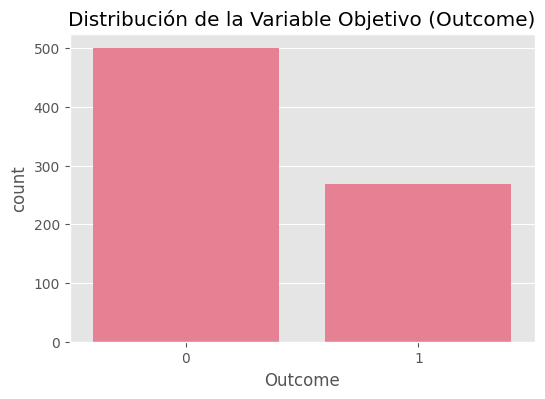

In [256]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=data)
plt.title('Distribución de la Variable Objetivo (Outcome)')
plt.show()

In [257]:
print("\nProporción de clases:")
print(data['Outcome'].value_counts(normalize=True))


Proporción de clases:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


## 4. Distribuciones por Outcome

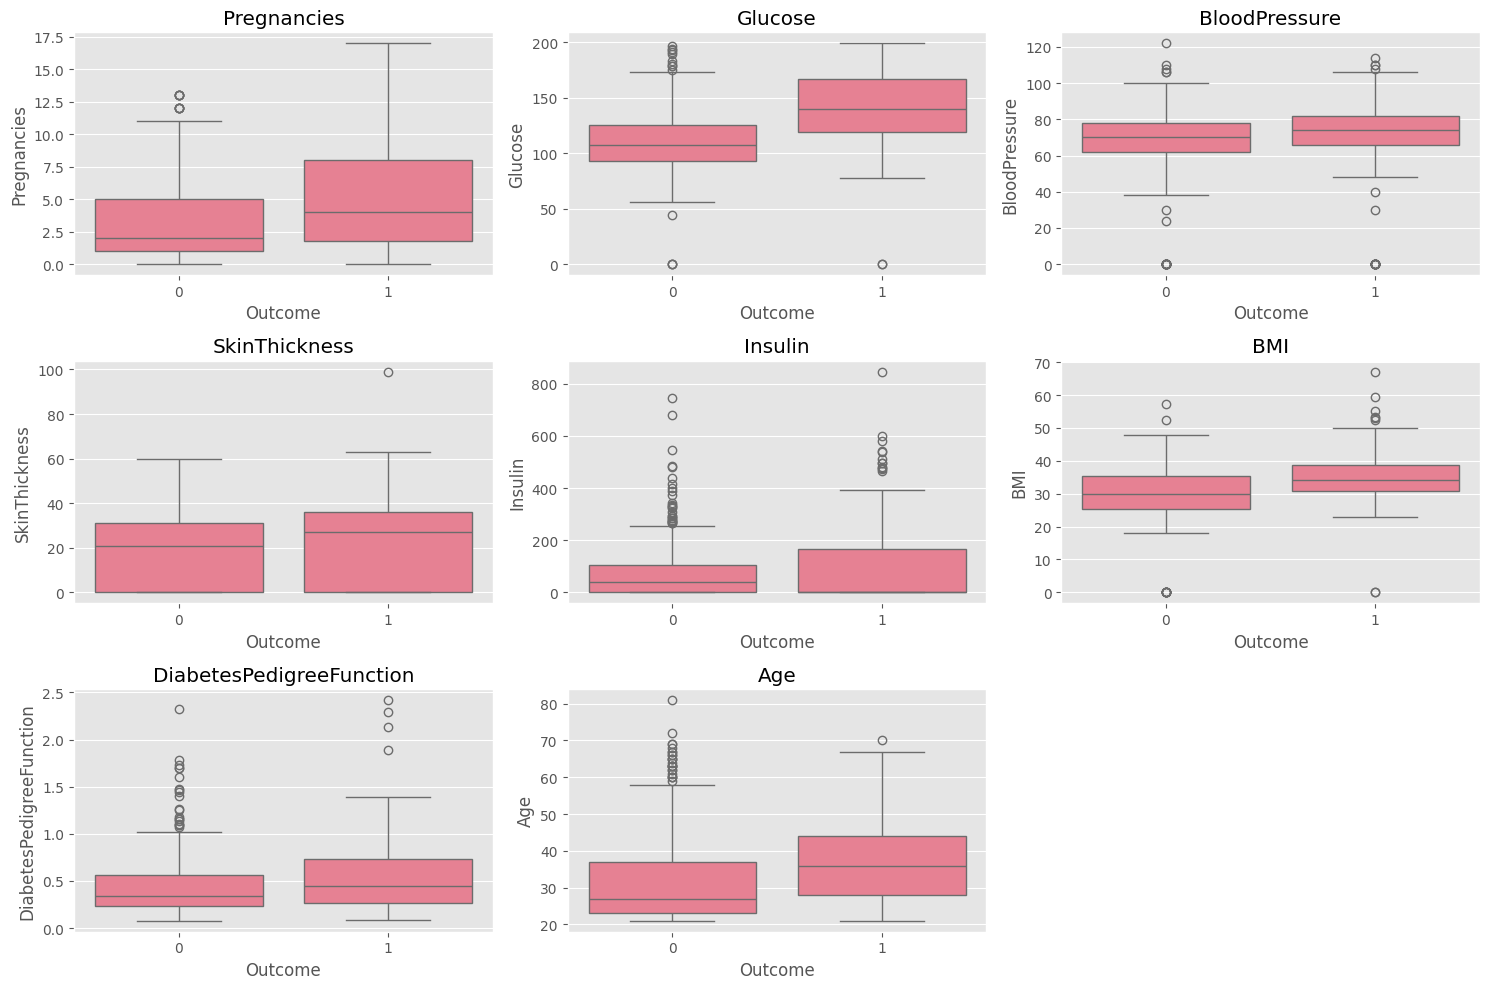

In [258]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(data.columns[:-1]):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x='Outcome', y=col, data=data)
    plt.title(col)
plt.tight_layout()
plt.show()

## 5. Matriz de correlación

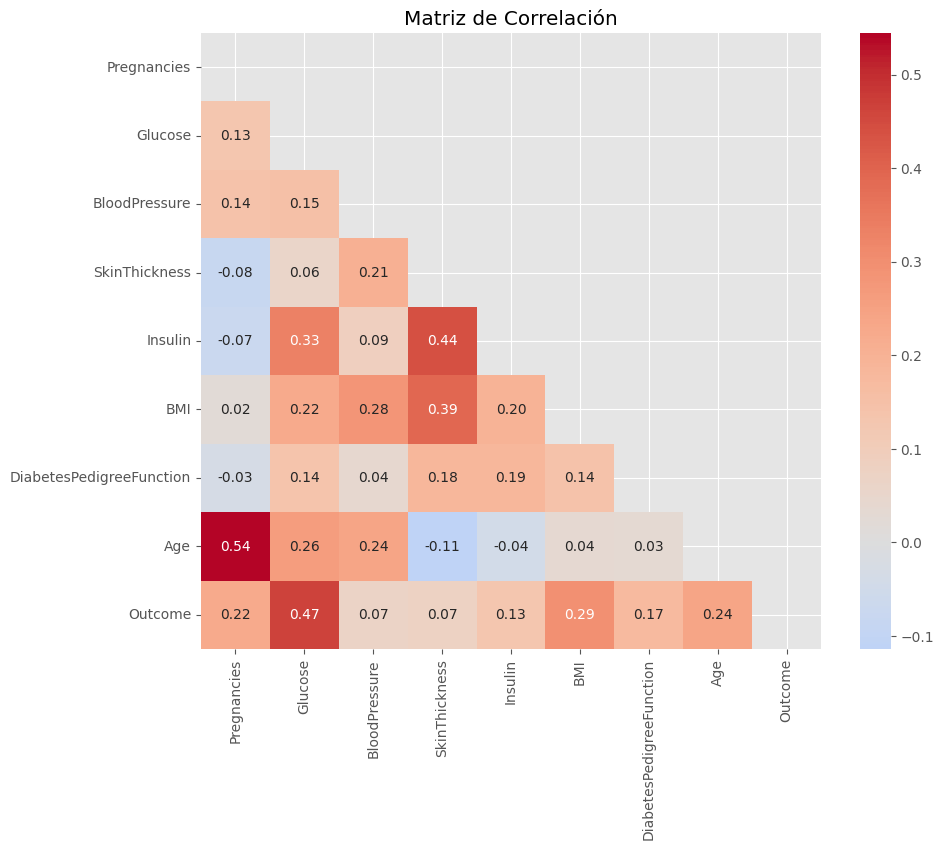

In [259]:
corr = data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 8))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title('Matriz de Correlación')
plt.show()

# 2. Preprocesamiento de Datos

## 1. Manejo de valores cero (missing values)

In [260]:
# Reemplazar ceros en ciertas columnas con NaN
data[cols_with_zero] = data[cols_with_zero].replace(0, np.nan)

In [261]:
# Imputar valores faltantes con la mediana
imputer = SimpleImputer(strategy='median')
data[cols_with_zero] = imputer.fit_transform(data[cols_with_zero])

## 2. Ingeniería de características

In [262]:
data['BMI_Glucose'] = data['BMI'] * data['Glucose']
data['Age_Glucose'] = data['Age'] * data['Glucose']

In [263]:
# Ver nuevas características
print("\nDataset con nuevas características:")
data.head()


Dataset con nuevas características:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMI_Glucose,Age_Glucose
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1,4972.8,7400.0
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0,2261.0,2635.0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1,4263.9,5856.0
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0,2500.9,1869.0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1,5904.7,4521.0


## 3. División en train y test

In [264]:
X = data.drop('Outcome', axis=1)
y = data['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                                   random_state=42, 
                                                   stratify=y)

## 4. Balanceo de clases con SMOTE (solo en el conjunto de entrenamiento)

In [265]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

In [266]:
print("\nDistribución antes de SMOTE:", y_train.value_counts())
print("Distribución después de SMOTE:", pd.Series(y_res).value_counts())


Distribución antes de SMOTE: Outcome
0    350
1    187
Name: count, dtype: int64
Distribución después de SMOTE: Outcome
1    350
0    350
Name: count, dtype: int64


**Para mayor claridad, modificavion ligeramente del código para mostrar las etiquetas de clase:**

In [267]:
print("\nDistribución antes de SMOTE:")
print(pd.Series(y_train).map({0: 'No Diabetes', 1: 'Diabetes'}).value_counts())

print("\nDistribución después de SMOTE:")
print(pd.Series(y_res).map({0: 'No Diabetes', 1: 'Diabetes'}).value_counts())


Distribución antes de SMOTE:
Outcome
No Diabetes    350
Diabetes       187
Name: count, dtype: int64

Distribución después de SMOTE:
Outcome
Diabetes       350
No Diabetes    350
Name: count, dtype: int64


# 3. Modelado y Optimización

## 1. Creación del pipeline

In [268]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(random_state=42))
])

## 2. Búsqueda de hiperparámetros

In [269]:
param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 5, 10],
    'classifier__min_samples_split': [2, 5, 10]
}

In [270]:
grid_search = GridSearchCV(pipeline, param_grid, cv=5, 
                          scoring='roc_auc', n_jobs=-1, verbose=1)
grid_search.fit(X_res, y_res)

Fitting 5 folds for each of 27 candidates, totalling 135 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'classifier__max_depth': [None, 5, 10],
                         'classifier__min_samples_split': [2, 5, 10],
                         'classifier__n_estimators': [100, 200, 300]},
             scoring='roc_auc', verbose=1)

## Resultados de la búsqueda

In [271]:
print("\nMejores parámetros:", grid_search.best_params_)
print("Mejor score (ROC AUC):", grid_search.best_score_)


Mejores parámetros: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300}
Mejor score (ROC AUC): 0.9012653061224489


## 3. Evaluación del mejor modelo

In [272]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

## Métricas de evaluación

In [273]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print(f"\nROC AUC: {roc_auc_score(y_test, y_proba):.3f}")


Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.79      0.80       150
           1       0.64      0.67      0.65        81

    accuracy                           0.75       231
   macro avg       0.73      0.73      0.73       231
weighted avg       0.75      0.75      0.75       231


ROC AUC: 0.829


## Matriz de confusión visual

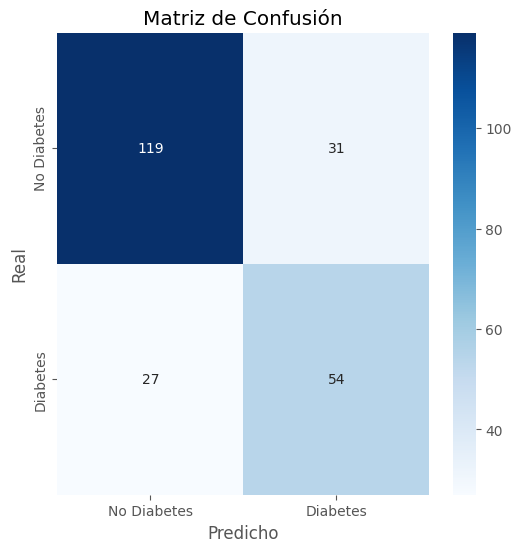

In [274]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Diabetes', 'Diabetes'], 
            yticklabels=['No Diabetes', 'Diabetes'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

# 4. Interpretabilidad del Modelo

## 1. Importancia de características

In [275]:
feature_importance = best_model.named_steps['classifier'].feature_importances_
features = X.columns
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importance})
importance_df = importance_df.sort_values('Importance', ascending=False)

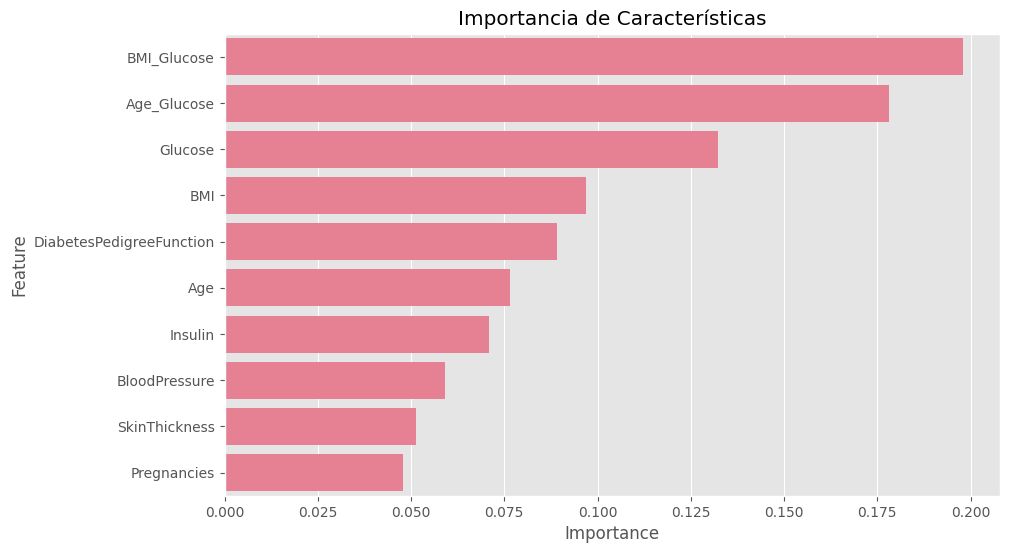

In [276]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df)
plt.title('Importancia de Características')
plt.show()

## 2. SHAP values para interpretabilidad


Verificación de dimensiones SHAP:
Forma de X_test_scaled: (231, 10)
Número de elementos SHAP: 231
Forma de SHAP para clase 0: (10, 2)
Forma de SHAP para clase 1: (10, 2)

Error con TreeExplainer: Dimensiones no coinciden
Usando enfoque alternativo...


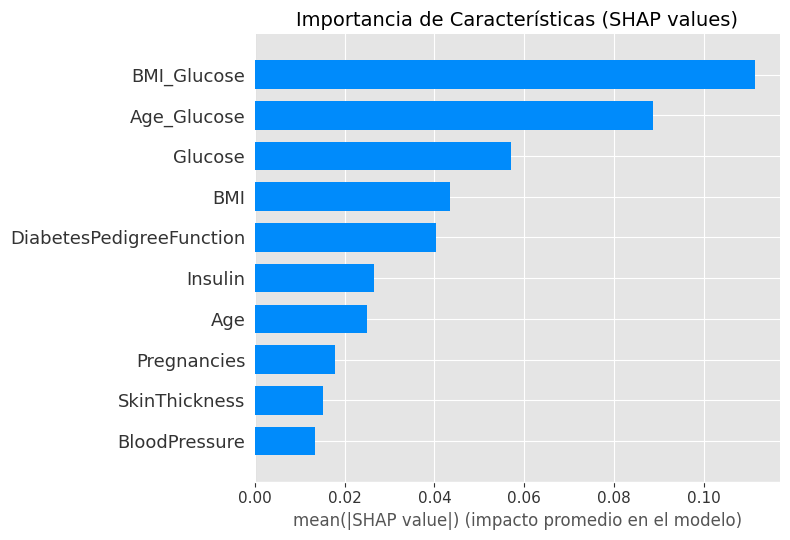

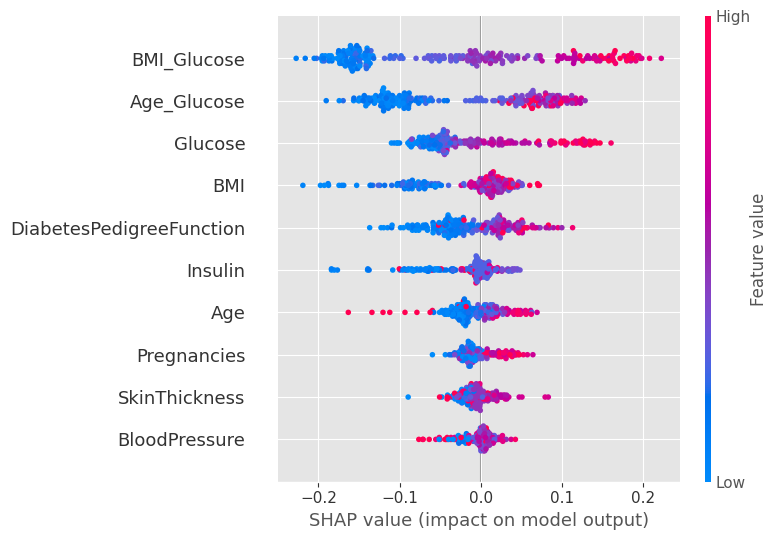

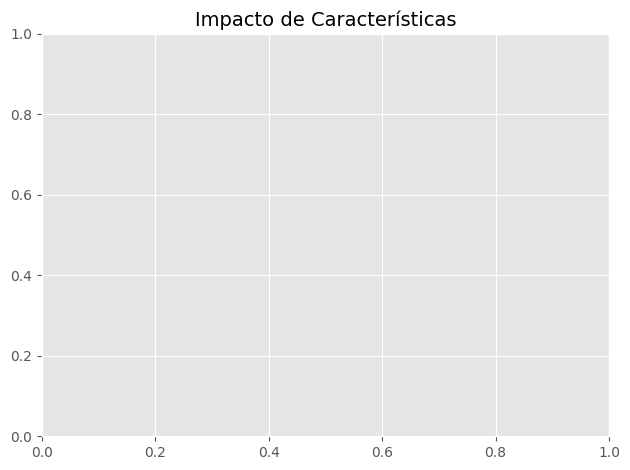


Explicación para una observación de ejemplo:


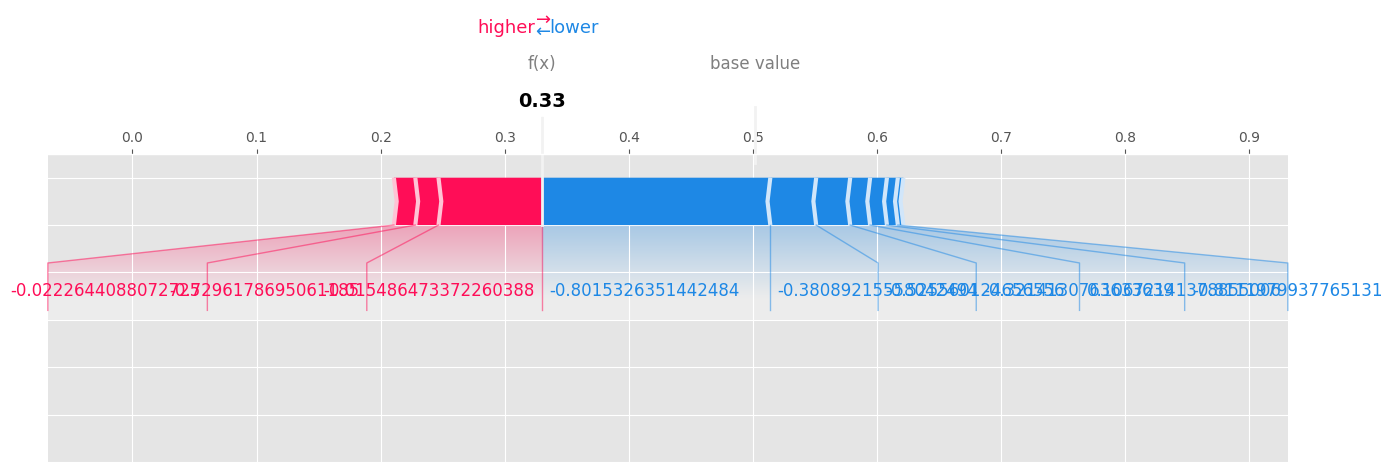

In [277]:
# Preparar los datos escalados
scaler = best_model.named_steps['scaler']
X_test_scaled = scaler.transform(X_test)
features = X_test.columns.tolist()  # Asegurar que features esté definido

# Versión robusta para calcular SHAP values
try:
    #TreeExplainer (más eficiente para modelos de árboles)
    explainer = shap.TreeExplainer(best_model.named_steps['classifier'])
    shap_values = explainer.shap_values(X_test_scaled)
    
    # Verificación de dimensiones
    print("\nVerificación de dimensiones SHAP:")
    print(f"Forma de X_test_scaled: {X_test_scaled.shape}")
    print(f"Número de elementos SHAP: {len(shap_values)}")
    print(f"Forma de SHAP para clase 0: {np.array(shap_values[0]).shape}")
    print(f"Forma de SHAP para clase 1: {np.array(shap_values[1]).shape}")

    if len(shap_values) == 2 and shap_values[1].shape == X_test_scaled.shape:
        # Gráfico de barras mejorado
        plt.figure(figsize=(12, 6))
        shap.summary_plot(shap_values[1], X_test_scaled, 
                         feature_names=features, 
                         plot_type='bar', 
                         show=False,
                         max_display=len(features))
        plt.title('Importancia de Características (SHAP values) - Diabetes', fontsize=14)
        plt.xlabel('mean(|SHAP value|) (impacto promedio en el modelo)', fontsize=12)
        plt.gca().xaxis.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

        # Gráfico de beeswarm
        plt.figure(figsize=(12, 6))
        shap.summary_plot(shap_values[1], X_test_scaled, 
                         feature_names=features,
                         show=False,
                         plot_size=(12, 6))
        plt.title('Impacto de Características en las Predicciones', fontsize=14)
        plt.tight_layout()
        plt.show()
        
        # Gráfico de fuerza para una observación de ejemplo
        print("\nExplicación para una observación de ejemplo:")
        shap.initjs()
        display(shap.force_plot(explainer.expected_value[1], 
                               shap_values[1][0,:], 
                               X_test_scaled[0,:],
                               feature_names=features,
                               matplotlib=True))
    else:
        raise ValueError("Dimensiones no coinciden")
        
except Exception as e:
    print(f"\nError con TreeExplainer: {str(e)}\nUsando enfoque alternativo...")
    
    # Enfoque alternativo con la API nueva
    explainer = shap.Explainer(best_model.named_steps['classifier'])
    sv = explainer(X_test_scaled)
    
    # Gráfico de barras
    plt.figure(figsize=(12, 6))
    shap.summary_plot(sv[:, :, 1].values, X_test_scaled, 
                     feature_names=features, 
                     plot_type='bar',
                     show=False)
    plt.title('Importancia de Características (SHAP values)', fontsize=14)
    plt.xlabel('mean(|SHAP value|) (impacto promedio en el modelo)', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Beeswarm plot
    plt.figure(figsize=(12, 6))
    shap.summary_plot(sv[:, :, 1].values, X_test_scaled, 
                     feature_names=features)
    plt.title('Impacto de Características', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    # Force plot para observación de ejemplo
    print("\nExplicación para una observación de ejemplo:")
    shap.plots.force(sv[0][:, 1], matplotlib=True, figsize=(16, 4))

# Interpretación de los Gráficos SHAP

## a) Gráfico de Barras (Importancia Global)

**Características más importantes:**

        1. BMI_Glucose (combinación de BMI y Glucosa): Impacto más alto (SHAP ≈ 0.10).

        2. Age_Glucose (combinación de Edad y Glucosa): SHAP ≈ 0.08.

        3. Glucose: SHAP ≈ 0.06.

    Estas 3 son las principales drivers del modelo.

## Interpretación:

* Las interacciones creadas (BMI_Glucose, Age_Glucose) son más importantes que las variables individuales, validando tu ingeniería de características.

* La glucosa (variable clínica clave en diabetes) sigue siendo crítica.


## b) Gráfico Beeswarm (Impacto por Muestra)

**Patrones clave:**

        1. BMI_Glucose:

           - Valores altos (rojos) → Aumentan riesgo de diabetes (SHAP positivo).

           - Valores bajos (azules) → Disminuyen riesgo (SHAP negativo).

        2. BloodPressure:

           - Impacto menor y disperso (SHAP cercano a 0).

## Interpretación:

* El modelo asigna mayor peso a pacientes con altos niveles combinados de BMI/Glucosa y Edad/Glucosa.

* Variables como SkinThickness o BloodPressure tienen poco impacto.

# 5. Visualizaciones

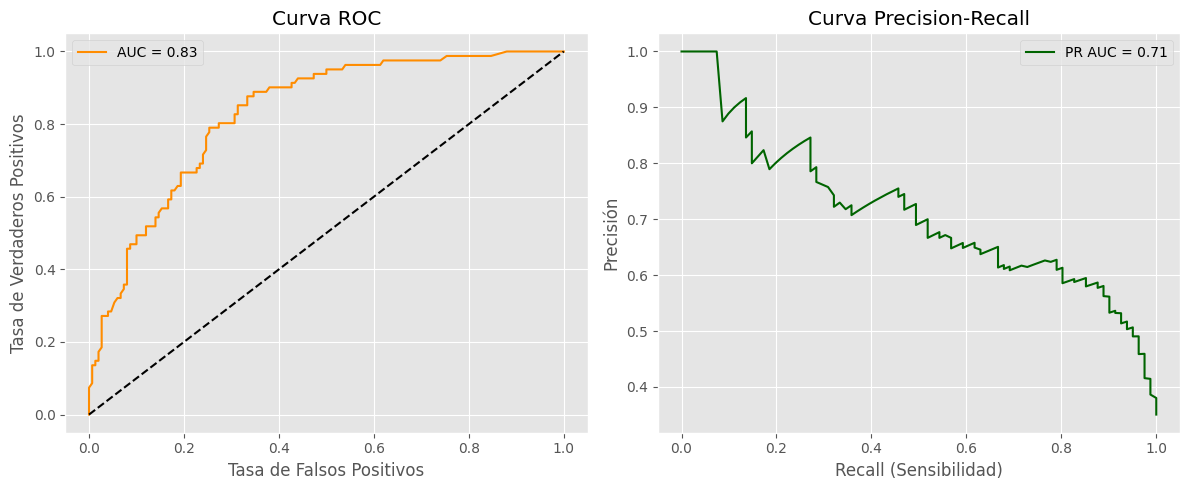

In [278]:
# 1. Curva ROC y Precision-Recall
fpr, tpr, _ = roc_curve(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_proba):.2f}', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(recall, precision, label=f'PR AUC = {auc(recall, precision):.2f}', color='darkgreen')
plt.xlabel('Recall (Sensibilidad)')
plt.ylabel('Precisión')
plt.title('Curva Precision-Recall')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_21088\160782708.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Clase Real')


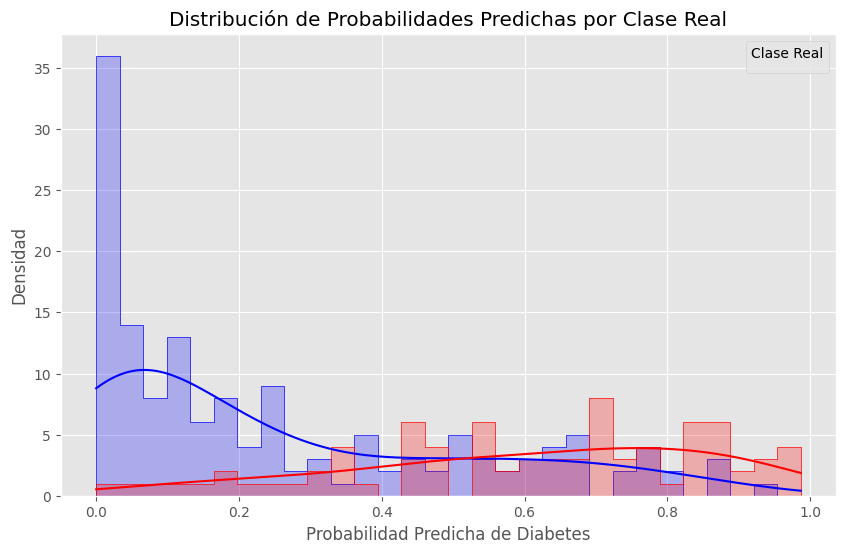

In [ ]:
# 2. Distribución de probabilidades
plt.figure(figsize=(10, 6))
# Convertir y_test a etiquetas para mejor visualización
y_test_labels = ['Diabetes' if x == 1 else 'No Diabetes' for x in y_test]
sns.histplot(
    x=y_proba, 
    hue=y_test_labels,
    bins=30, 
    kde=True, 
    element='step',
    palette={'Diabetes': 'red', 'No Diabetes': 'blue'},
    common_norm=False
)
plt.title('Distribución de Probabilidades Predichas por Clase Real')
plt.xlabel('Probabilidad Predicha de Diabetes')
plt.ylabel('Densidad')
plt.legend(title='Clase Real')
plt.show()

# 6. Validación Cruzada y Guardado del Modelo

In [280]:
# Validación cruzada más robusta 
cv_scores = cross_val_score(best_model, X_res, y_res, cv=10, scoring='roc_auc')
print(f"ROC AUC promedio en validación cruzada: {np.mean(cv_scores):.3f} ± {np.std(cv_scores):.3f}")

ROC AUC promedio en validación cruzada: 0.900 ± 0.045



Métricas de Validación Cruzada (10-folds):
ROC AUC: 0.900 ± 0.045
F1-Score: 0.838 ± 0.045
Precisión: 0.803 ± 0.053
Sensibilidad: 0.880 ± 0.065


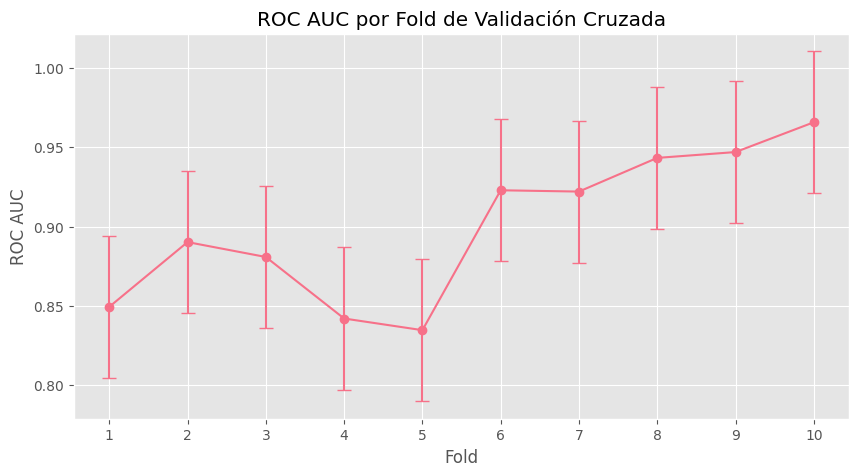

In [281]:
# 1. Validación cruzada con múltiples métricas de evaluación
scoring = {
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall'
}

cv_results = cross_validate(
    best_model,
    X_res,
    y_res,
    cv=10,
    scoring=scoring,
    return_train_score=True
)

# 2. Resultados detallados
print("\nMétricas de Validación Cruzada (10-folds):")
print(f"ROC AUC: {np.mean(cv_results['test_roc_auc']):.3f} ± {np.std(cv_results['test_roc_auc']):.3f}")
print(f"F1-Score: {np.mean(cv_results['test_f1']):.3f} ± {np.std(cv_results['test_f1']):.3f}")
print(f"Precisión: {np.mean(cv_results['test_precision']):.3f} ± {np.std(cv_results['test_precision']):.3f}")
print(f"Sensibilidad: {np.mean(cv_results['test_recall']):.3f} ± {np.std(cv_results['test_recall']):.3f}")

# 3. Visualización de resultados por fold
plt.figure(figsize=(10, 5))
plt.errorbar(
    range(1, 11),
    cv_results['test_roc_auc'],
    yerr=np.std(cv_results['test_roc_auc']),
    fmt='-o',
    capsize=5
)
plt.title('ROC AUC por Fold de Validación Cruzada')
plt.xlabel('Fold')
plt.ylabel('ROC AUC')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()